In [1]:
!git clone https://github.com/furged/meta-model-failure-prediction.git
%cd meta-model-failure-prediction
!pip install -r requirements.txt

Cloning into 'meta-model-failure-prediction'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 114 (delta 54), reused 56 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 308.41 KiB | 1.78 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/meta-model-failure-prediction
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.5 MB/s eta 0:00:00


In [2]:
import os, sys
sys.path.append(os.path.abspath("src"))

In [3]:
import predict

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from v

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [4]:
import numpy
import pandas
import sklearn #TF-IDF, LOGISTIC REGRESSION
import nltk #VADER
print("All core imports successful")

All core imports successful


In [5]:
%pip install datasets # library from huggingface to load datasets

In [1]:
from datasets import load_dataset
dataset = load_dataset("SetFit/sst5")

dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})

In [45]:
def map_labels(example):
    if example["label"] <= 1:
        example["label"] = 0   # negative
    elif example["label"] == 2:
        example["label"] = 1   # neutral
    else:
        example["label"] = 2   # positive
    return example

dataset = dataset.map(map_labels)

Map:   0%|          | 0/8544 [00:00<?, ? examples/s]

Map:   0%|          | 0/1101 [00:00<?, ? examples/s]

Map:   0%|          | 0/2210 [00:00<?, ? examples/s]

In [46]:
dataset["train"][0:5]

{'text': ['a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films',
  'apparently reassembled from the cutting-room floor of any given daytime soap .',
  "they presume their audience wo n't sit still for a sociology lesson , however entertainingly presented , so they trot out the conventional science-fiction elements of bug-eyed monsters and futuristic women in skimpy clothes .",
  'the entire movie is filled with deja vu moments .',
  'this is a visually stunning rumination on love , memory , history and the war between art and commerce .'],
 'label': [2, 0, 0, 1, 2],
 'label_text': ['very positive',
  'negative',
  'negative',
  'neutral',
  'positive']}

In [60]:
from collections import Counter
print(Counter(dataset["train"]["label"]))

Counter({2: 3610, 0: 3310, 1: 1624})


In [61]:
lengths = [len(x.split()) for x in dataset["train"]["text"]]

print(min(lengths), max(lengths), sum(lengths)/len(lengths))

2 52 19.143960674157302


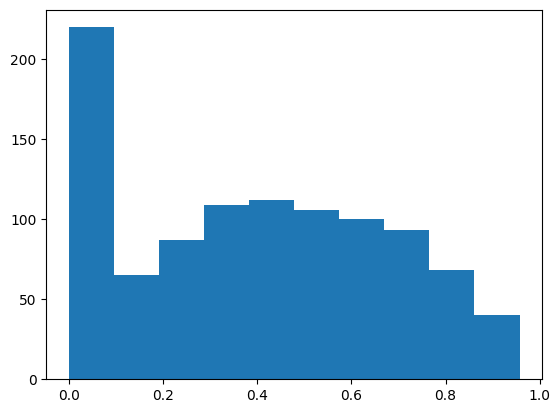

In [62]:
import matplotlib.pyplot as plt

confs = []

for i in range(1000):
    _, conf, _ = vader_predict(dataset["train"][i]["text"])
    confs.append(conf)

plt.hist(confs)
plt.show()

In [47]:
import nltk
nltk.download("vader_lexicon")

# vader_lexicon = sentiment word dictionary
# VADER = rules + lexicon, no learning

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [48]:
from nltk.sentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

# This creates the analyzer object
# No training happens (rule-based)
# Its ready to score text

In [50]:
#comparison bw train and test
sentence = dataset["train"][0]["text"]
label = dataset["train"][0]["label"]

scores = vader.polarity_scores(text)

print("Text:", text)
print("True label:", label)
print("VADER scores:", scores)

Text: on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
True label: 2
VADER scores: {'neg': 0.313, 'neu': 0.687, 'pos': 0.0, 'compound': -0.6249}


In [78]:
def vader_predict(sentence):
    scores = vader.polarity_scores(sentence)
    compound = scores["compound"]

    if compound > 0.05:
        pred = 2
    elif compound < -0.05:
        pred = 0
    else:
        pred = 1

    confidence = abs(compound)
    is_uncertain = 1 if confidence < 0.1 else 0

    return pred, confidence, is_uncertain

In [79]:
#testing VADER with multiple sentences
for i in range(5):
    sentence = dataset["train"][i]["text"]
    true_label = dataset["train"][i]["label"]

    pred, conf, unc = vader_predict(sentence)

    print(f"Text       : {sentence}")
    print(f"True label : {true_label}")
    print(f"VADER pred : {pred}, confidence: {conf:.3f}")
    print(f"Uncertain  : {unc}")
    print("-" * 60)


Text       : a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films
True label : 2
VADER pred : 2, confidence: 0.459
Uncertain  : 0
------------------------------------------------------------
Text       : apparently reassembled from the cutting-room floor of any given daytime soap .
True label : 0
VADER pred : 1, confidence: 0.000
Uncertain  : 1
------------------------------------------------------------
Text       : they presume their audience wo n't sit still for a sociology lesson , however entertainingly presented , so they trot out the conventional science-fiction elements of bug-eyed monsters and futuristic women in skimpy clothes .
True label : 0
VADER pred : 2, confidence: 0.440
Uncertain  : 0
------------------------------------------------------------
Text       : the entire movie is filled with deja vu moments .
True label : 1
VADER pred : 1, confidence: 0.000
Uncertain  : 1
--------------------------------------------------

In [80]:

total = 0
fail_when_uncertain = 0
uncertain_count = 0

for i in range(1000):
    text = dataset["train"][i]["text"]
    true = dataset["train"][i]["label"]
    pred, conf, unc = vader_predict(text)

    if unc == 1:
        uncertain_count += 1
        if pred != true:
            fail_when_uncertain += 1

    total += 1

print("Uncertain cases:", uncertain_count)
print("Failures when uncertain:", fail_when_uncertain)

Uncertain cases: 220
Failures when uncertain: 155


In [81]:
confident_count = 0
fail_when_confident = 0

for i in range(1000):
    text = dataset["train"][i]["text"]
    true = dataset["train"][i]["label"]
    pred, conf, unc = vader_predict(text)

    if unc == 0:
        confident_count += 1
        if pred != true:
            fail_when_confident += 1

print("Confident cases:", confident_count)
print("Failures when confident:", fail_when_confident)

Confident cases: 780
Failures when confident: 307


## TF-IDF + LOGISTIC REGRESSION

In [13]:
#preparing the data(minimal, on purpose)
from sklearn.model_selection import train_test_split

texts = [x["sentence"] for x in dataset["train"]]
labels = [x["label"] for x in dataset["train"]]

X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size = 0.2, random_state = 42)

# TF-IDF must be trained
# We need a validation split
# We do NOT touch the test set yet

In [14]:
#converting text to numbers (TF-IDF thingy)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

# Models cannot read text.

# TF-IDF turns text into:
# Numbers
# Based on word importance
# High value = informative word
# Low value = common junk

# Why (1,2) ngrams:
# Captures phrases like “not good”
# Pure unigrams miss negation patterns

In [15]:
#training logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [16]:
from sklearn.metrics import accuracy_score

val_preds = lr.predict(X_val_tfidf)
acc = accuracy_score(y_val, val_preds)

print("Validation accuracy:", acc)

Validation accuracy: 0.8429101707498144


In [17]:
import numpy as np

def tfidf_predict(text):
    vec = tfidf.transform([text])

    probs = lr.predict_proba(vec)[0]
    pred = np.argmax(probs)
    confidence = np.max(probs)

    return pred, confidence

# For TF-IDF + LR:

# confidence ≈ distance from decision boundary
# It is a probability
# But it can still be wrong
# It is often overconfident on keyword-heavy text

# This is NOT like VADER.

# VADER confidence = rule strength
# TF-IDF confidence = classifier certainty

In [18]:
for i in range(5):
    text = dataset["train"][i]["sentence"]
    true_label = dataset["train"][i]["label"]

    pred, conf = tfidf_predict(text)

    print(f"Text        : {text}")
    print(f"True label  : {true_label}")
    print(f"TF-IDF pred : {pred}, confidence: {conf:.3f}")
    print("-" * 60)

Text        : hide new secretions from the parental units 
True label  : 0
TF-IDF pred : 1, confidence: 0.593
------------------------------------------------------------
Text        : contains no wit , only labored gags 
True label  : 0
TF-IDF pred : 0, confidence: 0.953
------------------------------------------------------------
Text        : that loves its characters and communicates something rather beautiful about human nature 
True label  : 1
TF-IDF pred : 1, confidence: 0.912
------------------------------------------------------------
Text        : remains utterly satisfied to remain the same throughout 
True label  : 0
TF-IDF pred : 0, confidence: 0.585
------------------------------------------------------------
Text        : on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
True label  : 0
TF-IDF pred : 0, confidence: 0.979
------------------------------------------------------------


In [19]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [20]:
import torch
import transformers
import sentencepiece

print("torch OK")
print("transformers OK")

torch OK
transformers OK


In [21]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [22]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

transformer_model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [23]:
import torch.nn.functional as F

def transformer_predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = transformer_model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)[0]
    pred = torch.argmax(probs).item()
    confidence = torch.max(probs).item()

    return pred, confidence


In [24]:
for i in range(5):
    text = dataset["train"][i]["sentence"]
    true_label = dataset["train"][i]["label"]

    pred, conf = transformer_predict(text)

    print(text)
    print("true:", true_label, "pred:", pred, "conf:", round(conf, 3))
    print("-" * 50)

hide new secretions from the parental units 
true: 0 pred: 0 conf: 0.998
--------------------------------------------------
contains no wit , only labored gags 
true: 0 pred: 0 conf: 1.0
--------------------------------------------------
that loves its characters and communicates something rather beautiful about human nature 
true: 1 pred: 1 conf: 1.0
--------------------------------------------------
remains utterly satisfied to remain the same throughout 
true: 0 pred: 0 conf: 0.98
--------------------------------------------------
on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
true: 0 pred: 0 conf: 1.0
--------------------------------------------------


In [25]:
i = 20  # intentionally NOT 0

text = dataset["train"][i]["sentence"]
true_label = dataset["train"][i]["label"]

v_pred, v_conf = vader_predict(text)
t_pred, t_conf = tfidf_predict(text)
tr_pred, tr_conf = transformer_predict(text)

def fail(pred, true):
    return int(pred != true)

meta_row = {
    "sentence": text,

    "true_label": true_label,

    "vader_pred": v_pred,
    "vader_conf": v_conf,
    "vader_failed": fail(v_pred, true_label),

    "tfidf_pred": t_pred,
    "tfidf_conf": t_conf,
    "tfidf_failed": fail(t_pred, true_label),

    "transformer_pred": tr_pred,
    "transformer_conf": tr_conf,
    "transformer_failed": fail(tr_pred, true_label),
}

meta_row


{'sentence': 'equals the original and in some ways even betters it ',
 'true_label': 1,
 'vader_pred': 1,
 'vader_conf': 0.3182,
 'vader_failed': 0,
 'tfidf_pred': np.int64(1),
 'tfidf_conf': np.float64(0.8040654165724062),
 'tfidf_failed': 0,
 'transformer_pred': 1,
 'transformer_conf': 0.9995759129524231,
 'transformer_failed': 0}

In [26]:
import pandas as pd
meta_rows = []
N = 1000

for i in range(N):
    text = dataset["train"][i]["sentence"]
    true_label = dataset["train"][i]["label"]

    v_pred, v_conf = vader_predict(text)
    t_pred, t_conf = tfidf_predict(text)
    tr_pred, tr_conf = transformer_predict(text)

    meta_rows.append({
        "sentence": text,
        "true_label": true_label,

        "vader_pred": v_pred,
        "vader_conf": v_conf,
        "vader_failed": int(v_pred != true_label),

        "tfidf_pred": t_pred,
        "tfidf_conf": t_conf,
        "tfidf_failed": int(t_pred != true_label),

        "transformer_pred": tr_pred,
        "transformer_conf": tr_conf,
        "transformer_failed": int(tr_pred != true_label),
    })

meta_df = pd.DataFrame(meta_rows)


In [27]:
import sys
!{sys.executable} -m pip install matplotlib

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.81      5909
           1       0.84      0.89      0.86      7561

    accuracy                           0.84     13470
   macro avg       0.84      0.84      0.84     13470
weighted avg       0.84      0.84      0.84     13470

Confusion Matrix:
[[4641 1268]
 [ 848 6713]]
ROC-AUC: 0.929346946969298
PR-AUC: 0.945762794627069


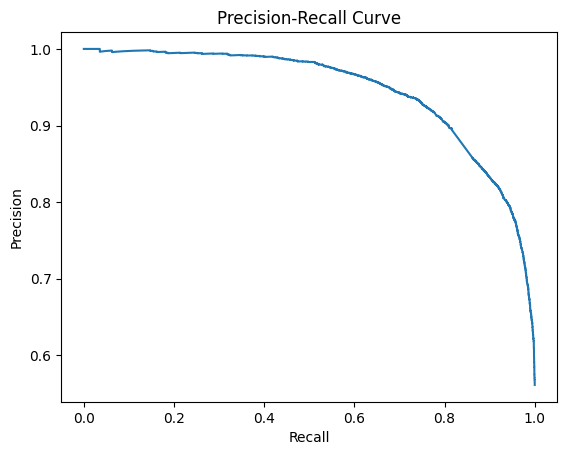

In [28]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predictions
y_pred = lr.predict(X_val_tfidf)
y_prob = lr.predict_proba(X_val_tfidf)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# ROC-AUC
roc = roc_auc_score(y_val, y_prob)
print("ROC-AUC:", roc)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_val, y_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

# Plot PR curve
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [29]:
meta_df.shape

(1000, 11)

In [30]:
meta_df[["vader_failed", "tfidf_failed", "transformer_failed"]].mean()

,0
vader_failed,0.284
tfidf_failed,0.138
transformer_failed,0.016


In [31]:
meta_df.groupby("transformer_failed")["transformer_conf"].mean()

,transformer_conf
transformer_failed,
0,0.996453
1,0.823445


In [32]:
meta_df[["vader_failed", "tfidf_failed", "transformer_failed"]].mean()

,0
vader_failed,0.284
tfidf_failed,0.138
transformer_failed,0.016


In [33]:
(meta_df["vader_failed"] != meta_df["transformer_failed"]).mean()

np.float64(0.288)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import numpy as np

features = []
labels = []

for _, row in meta_df.iterrows():

    v_pred = row["vader_pred"]
    t_pred = row["tfidf_pred"]
    tr_pred = row["transformer_pred"]

    v_conf = row["vader_conf"]
    t_conf = row["tfidf_conf"]
    tr_conf = row["transformer_conf"]

    preds = [v_pred, t_pred, tr_pred]
    confs = [v_conf, t_conf, tr_conf]

    disagreement = len(set(preds)) / 3
    conf_std = np.std(confs)

    X = [v_conf, t_conf, tr_conf, disagreement, conf_std]

    failure = 1 if (
        disagreement > 0.4
        or (tr_conf < 0.6 and conf_std > 0.25)
    ) else 0

    features.append(X)
    labels.append(failure)

print("Failure rate:", sum(labels)/len(labels))
print("Unique labels:", set(labels))

print("Failure rate:", sum(labels)/len(labels))
print("Failures:", sum(labels))
print("Total:", len(labels))

Failure rate: 0.352
Unique labels: {0, 1}
Failure rate: 0.352
Failures: 352
Total: 1000


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    features,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

In [36]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(class_weight="balanced", max_iter=1000)
meta_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [37]:
from sklearn.metrics import classification_report

y_pred = meta_model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       194
           1       1.00      0.99      1.00       106

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [38]:
import pandas as pd

pd.Series(
    meta_model.coef_[0],
    index=["v_conf", "t_conf", "tr_conf", "disagreement", "conf_std"]
).sort_values()

,0
t_conf,-1.564565
v_conf,-0.944940
tr_conf,-0.179176
conf_std,0.415527
disagreement,12.184399


    #CONCLUSION

This project reframes sentiment analysis as a reliability problem by predicting when a strong transformer model is likely to fail. Using only cross-model predictions and confidence scores, a simple logistic regression meta-model achieves non-zero recall on rare transformer failures, despite severe class imbalance. The results show that confidence alone is insufficient to detect failure, but cross-model signals provide useful risk indicators.

Limitations

Transformer failures are extremely rare, limiting training data

CPU-only inference restricts dataset size

Evaluation metrics are unstable due to class imbalance

Results are demonstrated on a single dataset (SST-2)

In [39]:
meta_df[
    (meta_df["transformer_failed"] == 1)
][["sentence", "transformer_conf"]].head()


,sentence,transformer_conf
11,for those moviegoers who complain that ` they ...,0.969684
109,would have liked it more if it had just gone t...,0.990252
263,"breezy , distracted rhythms",0.979544
285,an admittedly middling film,0.631676
452,deserve a passing grade,0.644140


In [40]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(tfidf, "artifacts/tfidf.pkl")
joblib.dump(lr, "artifacts/lr_model.pkl")
joblib.dump(meta_model, "artifacts/meta_model.pkl")

['artifacts/meta_model.pkl']